Neither CUDA nor MPS are available - defaulting to CPU. Note: This module is much faster with a GPU.



Extracted Text from Image (Confidence > 0.3):
Text: INCOME TAX DEPARTMENT, Confidence: 0.79
Text: GOVT OF INDIA, Confidence: 0.93
Text: Permanent Account Number Card, Confidence: 0.82
Text: FNMPR4593H, Confidence: 1.00
Text: Name, Confidence: 1.00
Text: PITHANI TARUN RoHIT SAI, Confidence: 0.73
Text: Father's Name, Confidence: 0.80
Text: PITHANI MURALIKRISHNA, Confidence: 0.99
Text: 06032023, Confidence: 1.00
Text: Date of Birth, Confidence: 0.96
Text: 28/06/2004, Confidence: 0.85
Text: €e / Signature, Confidence: 0.30


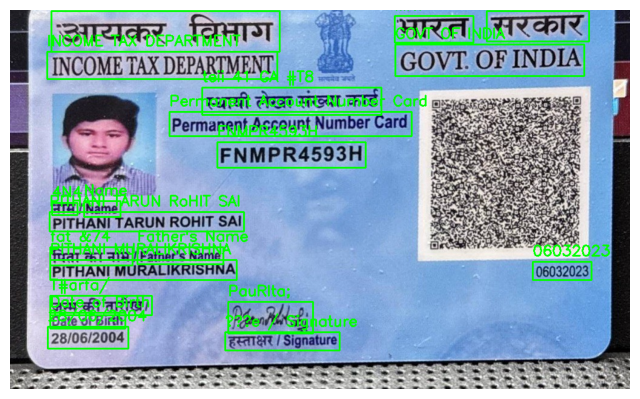


✅ Detected Fields:
PAN Number : FNMPR4593H (Confidence: 1.00)
DOB        : 28/06/2004 (Confidence: 0.85)
Person Name: PITHANI TARUN RoHIT SAI (Confidence: 0.73)
Father Name: Father's Name (Confidence: 0.80)

📸 Annotated image saved as 'annotated_output.jpg'


In [22]:
import easyocr
import cv2
import matplotlib.pyplot as plt
import re

def extract_text_and_probs(image_path):
    reader = easyocr.Reader(['en'])
    img = cv2.imread(image_path)
    results = reader.readtext(img)

    entries = []
    print("\nExtracted Text from Image (Confidence > 0.3):")
    for bbox, text, prob in results:
        (tl, _, br, _) = bbox
        tl = tuple(map(int, tl))
        br = tuple(map(int, br))
        cv2.rectangle(img, tl, br, (0,255,0), 2)
        cv2.putText(img, text, (tl[0], tl[1]-10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0,255,0), 2)

        if prob > 0.3:
            print(f"Text: {text}, Confidence: {prob:.2f}")
            entries.append({
                'text': text.strip(),
                'prob': prob,
                'bbox': bbox,
                'y_center': (tl[1] + br[1]) // 2
            })

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(8,8))
    plt.imshow(img_rgb)
    plt.axis('off')
    plt.show()

    return entries, img

def detect_pan_and_dob(entries):
    pan_pat = re.compile(r'^[A-Z]{5}[0-9]{4}[A-Z]$')
    dob_pat = re.compile(r'\b\d{2}/\d{2}/\d{4}\b')

    pan_idx = dob_idx = None
    for i, e in enumerate(entries):
        if pan_idx is None and pan_pat.fullmatch(e['text']):
            pan_idx = i
        if dob_idx is None and dob_pat.search(e['text']):
            dob_idx = i
        if pan_idx is not None and dob_idx is not None:
            break

    pan = entries[pan_idx] if pan_idx is not None else {'text': None, 'prob': 0.0}
    dob = {'text': None, 'prob': 0.0}
    if dob_idx is not None:
        m = dob_pat.search(entries[dob_idx]['text'])
        if m:
            dob = {
                'text': m.group(0),
                'prob': entries[dob_idx]['prob']
            }

    return pan, pan_idx, dob, dob_idx

def find_names(entries):
    # Filter valid name candidates
    name_candidates = [
        e for e in entries
        if len(e['text'].split()) >= 2
        and e['prob'] > 0.3
        and not any(x in e['text'].upper() for x in [
            "INCOME", "TAX", "GOVT", "INDIA", "SIGNATURE", "ACCOUNT", "DATE", "PERMANENT", "NUMBER"
        ])
        and '/' not in e['text']
        and not re.match(r'^[A-Z]{5}[0-9]{4}[A-Z]$', e['text'])
    ]

    # Sort by y_center (vertical position)
    name_candidates.sort(key=lambda e: e['y_center'])

    if len(name_candidates) >= 2:
        # Assume top name is person, next is father
        person = name_candidates[0]
        father = name_candidates[1]
    elif len(name_candidates) == 1:
        person = name_candidates[0]
        father = {'text': None, 'prob': 0.0}
    else:
        person = father = {'text': None, 'prob': 0.0}

    return person, father

def main(image_path):
    entries, img = extract_text_and_probs(image_path)

    pan, pan_idx, dob, dob_idx = detect_pan_and_dob(entries)
    person, father = find_names(entries)

    print("\n✅ Detected Fields:")
    print(f"PAN Number : {pan['text']} (Confidence: {pan['prob']:.2f})")
    print(f"DOB        : {dob['text']} (Confidence: {dob['prob']:.2f})")
    if person['text']:
        print(f"Person Name: {person['text']} (Confidence: {person['prob']:.2f})")
    else:
        print("Person Name: None")
    if father['text']:
        print(f"Father Name: {father['text']} (Confidence: {father['prob']:.2f})")
    else:
        print("Father Name: None")

    cv2.imwrite('annotated_output.jpg', img)
    print("\n📸 Annotated image saved as 'annotated_output.jpg'")

if __name__ == "__main__":
    main("pancard/15.jpg")  # Replace with your image path


In [ ]:
import easyocr
import cv2
import matplotlib.pyplot as plt
import re
import json
import numpy as np

# JSON Configuration
config = {
    "PAN_Card": {
        "Type": "PAN",
        "Keywords": ["Permanent Account Number Card", "Permanent Account Number", "INCOME TAX DEPARTMENT", "GOVT. OF INDIA"],
        "PAN_No": {
            "Format": "Pattern",
            "Pattern": r"([A-Z]{5}\s*[0-9O]{4}\s*[A-Z]{1})",
        },
        "Person_Name": {
            "Format": "Text",
            "Heading": ["Name"]
        },
        "DOB": {
            "Format": "Date",
            "Pattern": r"(\d{2}/\d{2}/\d{4})",
            "Heading": ["Date of Birth", "जन्म की तारीख/", "जन्म की तारीख", "Daie ol Birth", "जन्म को तारीख", "Date ot Birth"] # Includes OCR variations
        },
        "Father_Name": {
            "Format": "Text",
            "Heading": ["Father's Name"] 
        }
    },
    "Aadhaar_Card_Front": {
        "Type": "Aadhaar",
        "Keywords": ["Government of India", "GOVT. OF INDIA", "Aadhaar", " आधार", "Enrolment No"],
        "Back_Keywords": [],
        "Aadhaar_No": {
            "Format": "Pattern",
            "Pattern": r"(\d{4}\s*\d{4}\s*\d{4})(?!\s*\d)", # Avoid matching VID
        },
        "Person_Name": {
            "Format": "Text",
            "Heading": [] 
        },
        "DOB": {
            "Format": "Date",
            "Pattern": r"DOB\s*[:]?\s*(\d{2}/\d{2}/\d{4})",
        },
        "Gender": {
            "Format": "Text",
            "Options": ["male", "female", "Male", "Female", "MALE", "FEMALE"],
            "Pattern": r"(Male|Female|MALE|FEMALE)",
        }
    },
    "Aadhaar_Card_Back": {
        "Type": "Aadhaar",
        "Keywords": ["Aadhaar", " आधार", "Unique Identification Authority of India"],
        "Back_Keywords": ["Address:", " पता:", "Unique Identification Authority of India", r"Address\s*:?"],
        "Address": {
            "Format": "MultilineText",
            
            "Heading": ["Address:", " पता:", r"Address\s*[:]??"],
            "StopKeywords": [
                r"^\s*VID", r"^\s*Mobile", r"^\s*Email", r"^\s*Phone",
                r"www\.uidai\.gov\.in", r"help@uidai\.gov\.in",
                r"^\s*1[89]00", # Toll-free numbers starting with 1800 or 1900
                r"^\s*\d{4}\s+\d{4}\s+\d{4}\s+\d{4}", # VID pattern at start of line
                r"^\s*\d{4}\s+\d{4}\s+\d{4}(?!\s*\d)" # Aadhaar number pattern at start (but not VID)
                ]
        }
    }
}


def identify_document_type(text, config):
    detected_type = "Unknown"
    text_lower = text.lower()
    primary_match = None
    is_back = False


    pan_keywords_found = 0
    aadhaar_keywords_found = 0

    if "PAN_Card" in config:
        for keyword in config["PAN_Card"].get("Keywords", []):
            if re.search(r'\b' + re.escape(keyword.lower()) + r'\b', text_lower):
                pan_keywords_found += 1

    if "Aadhaar_Card_Front" in config:
       for keyword in config["Aadhaar_Card_Front"].get("Keywords", []):
            if re.search(r'\b' + re.escape(keyword.lower()) + r'\b', text_lower):
                aadhaar_keywords_found += 1

    if "Aadhaar_Card_Back" in config:
        for keyword in config["Aadhaar_Card_Back"].get("Keywords", []):
             if keyword not in config["Aadhaar_Card_Front"].get("Keywords", []) and \
                re.search(r'\b' + re.escape(keyword.lower()) + r'\b', text_lower):
                  aadhaar_keywords_found += 1

    
    if pan_keywords_found > aadhaar_keywords_found and pan_keywords_found >= 1: primary_match = "PAN_Card"
    elif aadhaar_keywords_found > pan_keywords_found and aadhaar_keywords_found >= 1: primary_match = "Aadhaar"
    elif pan_keywords_found >= 1 and aadhaar_keywords_found == 0: primary_match = "PAN_Card"
    elif aadhaar_keywords_found >= 1 and pan_keywords_found == 0: primary_match = "Aadhaar"


    if primary_match == "Aadhaar" and "Aadhaar_Card_Back" in config:
        for keyword_pattern in config["Aadhaar_Card_Back"].get("Back_Keywords", []):
            try:
                if re.search(keyword_pattern, text, re.IGNORECASE): is_back = True; break
            except re.error:
                 if keyword_pattern.lower() in text_lower: is_back = True; break

    
    if primary_match == "PAN_Card": detected_type = "PAN_Card"
    elif primary_match == "Aadhaar": detected_type = "Aadhaar_Card_Back" if is_back else "Aadhaar_Card_Front"
    else:
        # Fallback to pattern matching if no keywords matched
        if "PAN_Card" in config and re.search(config["PAN_Card"]["PAN_No"]["Pattern"], text):
            detected_type = "PAN_Card"
        elif "Aadhaar_Card_Front" in config and re.search(config["Aadhaar_Card_Front"]["Aadhaar_No"]["Pattern"], text):
            if "Aadhaar_Card_Back" in config:
                 for keyword_pattern in config["Aadhaar_Card_Back"].get("Back_Keywords", []):
                     try:
                        if re.search(keyword_pattern, text, re.IGNORECASE): is_back = True; break
                     except re.error:
                          if keyword_pattern.lower() in text_lower: is_back = True; break
            detected_type = "Aadhaar_Card_Back" if is_back else "Aadhaar_Card_Front"

    return detected_type



def find_value_after_heading(lines, headings, max_lines_to_check=1, field_name=None):
    
    for i, line in enumerate(lines):
        line_lower = line.lower()
        for heading in headings:
             if re.search(r'[\u0900-\u097F]', heading): continue # Skip Hindi

             heading_lower = heading.lower()
             match_found = False
             start_index = -1

             
             try:
                 pattern_to_search = heading
                 if not re.search(r'[\\^$.*+?{}\[\]|()]', heading):
                      pattern_to_search = r'^\s*' + re.escape(heading_lower) + r'\s*[:/l|]?\s*'

                 match_obj = re.match(pattern_to_search, line, re.IGNORECASE)
                 if match_obj: match_found = True; start_index = match_obj.end()
             except re.error:
                  if line_lower.strip().startswith(heading_lower):
                       match_found = True; start_index = len(heading_lower)
                       if len(line) > start_index and line[start_index] in ': ': start_index +=1

             
             if match_found and start_index != -1:
                 value_on_line = line[start_index:].strip()

            
                 if value_on_line and not re.match(r"^(Name|Father'?s? Name|Address|DOB|Date of Birth|Gender)\b", value_on_line, re.IGNORECASE):
                      return value_on_line

                 
                 if i + 1 < len(lines):
                     next_line_value = lines[i + 1].strip()
                     if next_line_value:
                         is_label = re.match(r'^(DOB|VID|PIN|Date|Birth|Account|Number|Address|Gender|Male|Female|Signature|Father|Name|Permanent|Income)\b', next_line_value, re.IGNORECASE)
                         is_pan_id = re.fullmatch(r'[A-Z]{5}\s*[0-9O]{4}\s*[A-Z]{1}', next_line_value)
                         is_aadhaar_id = re.fullmatch(r'\d{4}\s*\d{4}\s*\d{4}(?!\s*\d)', next_line_value)
                         if not is_label and not is_pan_id and not is_aadhaar_id:
                             return next_line_value

                 if value_on_line: return value_on_line 
                 break 
    return None


def extract_text_by_heading_refined(lines, headings, field_name=None, doc_type="Unknown"):

    english_headings = [h for h in headings if not re.search(r'[\u0900-\u097F]', h)]
    if not english_headings: return None
    value = find_value_after_heading(lines, english_headings, max_lines_to_check=1, field_name=field_name)
    if value:
        if field_name == "DOB":
             date_match = re.search(r'(\d{2}/\d{2}/\d{4})', value)
             return date_match.group(1) if date_match else value.strip()
        else: return value.strip()
    return None


def extract_aadhaar_front_name_positionally(lines):
    name = None
    try:
         govt_line_index = -1
         for i, line in enumerate(lines):
              if re.search(r'government\s+of\s+india|govt\.\s+of\s+india', line, re.IGNORECASE):
                   govt_line_index = i; break
         if govt_line_index != -1 and govt_line_index + 1 < len(lines):
              potential_name_line = lines[govt_line_index + 1].strip()
              if potential_name_line and len(potential_name_line) > 2 and \
                 not re.search(r'DOB|Date of Birth|Gender|Male|Female|Address|Aadhaar|Enrolment', potential_name_line, re.IGNORECASE) and \
                 not re.search(r'\d{2}/\d{2}/\d{4}', potential_name_line) and \
                 not re.search(r'\d{4}\s*\d{4}\s*\d{4}', potential_name_line):
                    cleaned_name = re.sub(r'\s*[\d\W_]+$', '', potential_name_line).strip()
                    if cleaned_name: name = " ".join(cleaned_name.split()[:4])
    except Exception as e: pass
    return name


def extract_pan_names_positionally(lines):
    person_name = None
    father_name = None
    dob_line_index = -1
    pan_no_line_index = -1
    pan_no_value = None
    header_line_index = -1 

    
    dob_pattern = r'\d{2}/\d{2}/\d{4}'
    pan_pattern = config["PAN_Card"]["PAN_No"]["Pattern"]
    
    header_keywords = [kw.lower() for kw in config["PAN_Card"].get("Keywords", []) if "Permanent" in kw or "INCOME" in kw or "GOVT" in kw]

    for i, line in enumerate(lines):
        line_lower = line.lower()

        if dob_line_index == -1 and re.search(dob_pattern, line): dob_line_index = i
    
        pan_match = re.search(pan_pattern, line)
        if pan_no_line_index == -1 and pan_match:
            pan_no_line_index = i
            pan_no_value = pan_match.group(1) if pan_match.groups() else pan_match.group(0)
            pan_no_value = re.sub(r'\s', '', pan_no_value) if pan_no_value else None
        
        if header_line_index == -1:
            for keyword in header_keywords:
                
                if keyword in line_lower:
                    header_line_index = i
                    
                    break 


    father_line_found_at = -1

    
    father_search_start = dob_line_index - 1 if dob_line_index is not None else -1
    father_search_end = header_line_index + 1 if header_line_index != -1 else 0

    if father_search_start >= father_search_end:
        for i in range(father_search_start, father_search_end - 1, -1):
            if i < 0 or i >= len(lines): continue
            potential_father_line = lines[i].strip()
        
            if potential_father_line:
                cleaned_father_name = re.sub(r'\s+(?:Father[\'"\$s]*\s*Name|Father)\s*$', '', potential_father_line, flags=re.IGNORECASE).strip()
                cleaned_father_name = re.sub(dob_pattern, '', cleaned_father_name).strip()
                
                if len(cleaned_father_name) > 2 and re.match(r"^[A-Z\s\-\./]+$", cleaned_father_name, re.IGNORECASE):
                     father_name = " ".join(cleaned_father_name.split()[:4])
                     father_line_found_at = i
            
                     break 

    
    person_search_start = header_line_index + 1 if header_line_index != -1 else 0
    person_search_end = (father_line_found_at if father_line_found_at != -1 else dob_line_index) if dob_line_index != -1 else len(lines)
    
    person_search_end = person_search_end

    

    if person_search_start < person_search_end:
         for i in range(person_search_start, person_search_end): 
              if i >= 0 and i < len(lines): 
                  potential_person_line = lines[i].strip()
                  
                  if potential_person_line:
                      if re.search(r'GOVT|INCOME|PERMANENT|ACCOUNT|NUMBER|CARD', potential_person_line, re.IGNORECASE):
                          
                          continue

                      
                      cleaned_person_name = re.sub(r'^\s*\W*[\w\d]{1,4}[\W\s]+(Name)?\s*', '', potential_person_line, flags=re.IGNORECASE).strip()
                      cleaned_person_name = re.sub(r'\s+Name\s*$', '', cleaned_person_name, flags=re.IGNORECASE).strip()
                      if pan_no_value and cleaned_person_name.endswith(pan_no_value):
                           cleaned_person_name = cleaned_person_name[:-len(pan_no_value)].strip()
                

                      if len(cleaned_person_name) > 2 and \
                         re.match(r"^[A-Z\s\-\./]+$", cleaned_person_name, re.IGNORECASE):
                           if not (father_name and cleaned_person_name == father_name):
                               person_name = " ".join(cleaned_person_name.split()[:4])
                               
                               break 
              else: 
                break

    return person_name, father_name



def extract_aadhaar_back_address(lines, config):
    """Extracts multiline Address from Aadhaar Back."""
    address_lines = []
    start_line_index = -1
    text_after_heading = ""

    address_config = config["Aadhaar_Card_Back"]["Address"]
    headings = address_config.get("Heading", [])
    stop_keywords = address_config.get("StopKeywords", [])

    english_headings = [h for h in headings if not re.search(r'[\u0900-\u097F]', h)]
    if not english_headings: return None

    for i, line in enumerate(lines):
        line_strip = line.strip()
        for heading_pattern in english_headings:
             try:
                
                 search_pattern = r'(?i)(?:^.*?\W)?' + heading_pattern.replace("Address:", r"Address\s*:?")
                 match = re.search(search_pattern, line_strip)
                 if match:
                     start_line_index = i
                     start_char_index = match.end()
                     text_on_same_line = line_strip[start_char_index:].strip()
                     if text_on_same_line and not re.match(r'^\s*(VID|Mobile|Phone|\d{4}\s*\d{4})', text_on_same_line, re.IGNORECASE):
                         text_after_heading = text_on_same_line
                     break
             except re.error: continue
        if start_line_index != -1: break

    if start_line_index == -1: return None

    
    if text_after_heading: address_lines.append(text_after_heading)

    for i in range(start_line_index + 1, len(lines)):
        current_line = lines[i].strip()
        if not current_line: continue
        stopped = False
        for stop_pattern in stop_keywords:
            try:
                
                if re.match(r"{}".format(stop_pattern), current_line, re.IGNORECASE):
                     stopped = True; break
            except re.error:
                if current_line.lower().startswith(stop_pattern.lower()):
                    stopped = True; break
        if stopped: break
        
        if re.match(r'^\s*([A-Z]+\s+)?\d{6}\s*$', current_line) and len(address_lines) >= 1:
             address_lines.append(current_line); break 
        address_lines.append(current_line)

    return "\n".join(address_lines).strip() if address_lines else None



def extract_details_typed(lines, text_blob, config, doc_type):
    """Extracts details based on identified doc_type."""
    extracted_data = {}
    if doc_type == "Unknown" or doc_type not in config:
        return { "Error": "Document type could not be reliably identified.", "Type": doc_type }

    type_config = config[doc_type]
    extracted_data[doc_type] = {}

    # Pre-computation for PAN Names
    pan_person_name, pan_father_name = None, None
    if doc_type == "PAN_Card":
        pan_person_name, pan_father_name = extract_pan_names_positionally(lines)
        if pan_person_name: extracted_data[doc_type]["Person_Name"] = pan_person_name
        if pan_father_name: extracted_data[doc_type]["Father_Name"] = pan_father_name

    # Pre-computation for Aadhaar Front Name
    aadhaar_person_name = None
    if doc_type == "Aadhaar_Card_Front":
        aadhaar_person_name = extract_aadhaar_front_name_positionally(lines)
        if aadhaar_person_name: extracted_data[doc_type]["Person_Name"] = aadhaar_person_name

    # Iterate through configured fields
    for field_name, field_config in type_config.items():
        if field_name in ["Keywords", "Back_Keywords", "Type"]: continue
        # Skip names if already found positionally above
        if doc_type == "PAN_Card" and field_name in ["Person_Name", "Father_Name"] and extracted_data[doc_type].get(field_name): continue
        if doc_type == "Aadhaar_Card_Front" and field_name == "Person_Name" and extracted_data[doc_type].get(field_name): continue

        # Initialize if not found positionally
        if field_name not in extracted_data[doc_type]: extracted_data[doc_type][field_name] = None

        value = None # Reset value for current field processing

        fmt = field_config.get("Format")
        headings = field_config.get("Heading", [])
        pattern_str = field_config.get("Pattern")
        options_en = [opt for opt in field_config.get("Options", []) if not re.search(r'[\u0900-\u097F]', opt)]

        # --- Extraction Logic ---

        # 1. Pattern Matching (IDs, DOB pattern)
        if pattern_str:
            match = re.search(pattern_str, text_blob, re.IGNORECASE)
            if match:
                value = match.group(1).strip() if match.groups() else match.group(0).strip()
                if field_name == "Aadhaar_No": value = re.sub(r'\s', '', value)
                # Ensure captured group is used for DOB/PAN if defined
                if field_name in ["DOB", "PAN_No"] and match.groups(): value = match.group(1).strip()

        # 2. Heading-Based Extraction (DOB fallback, Gender)
        if value is None and headings and fmt in ["Text", "Date"] and field_name not in ["Person_Name", "Father_Name", "Address"]:
             value = extract_text_by_heading_refined(lines, headings, field_name=field_name, doc_type=doc_type)

        # 3. Address Extraction (Specific function for Aadhaar Back)
        elif field_name == "Address" and doc_type == "Aadhaar_Card_Back":
             value = extract_aadhaar_back_address(lines, config)

        # 4. Gender Fallback
        elif field_name == "Gender" and value is None:
             dob_line_index = -1
             dob_headings = [h for h in config.get(doc_type, {}).get("DOB", {}).get("Heading", []) if not re.search(r'[\u0900-\u097F]', h)]
             for i,line in enumerate(lines):
                 if any(dh.lower() in line.lower() for dh in dob_headings) or re.search(r'\d{2}/\d{2}/\d{4}', line):
                     dob_line_index = i; break
             if dob_line_index != -1:
                 search_area = lines[dob_line_index] + ("\n" + lines[dob_line_index+1] if dob_line_index+1 < len(lines) else "")
                 for option in options_en:
                      if re.search(r'\b' + option + r'\b', search_area, re.IGNORECASE):
                        value = option; break

        # Assign value if found AND not already set positionally
        if value is not None and extracted_data[doc_type].get(field_name) is None:
            extracted_data[doc_type][field_name] = value.strip()

    # Final cleanup / Post-processing
    if "DOB" in extracted_data.get(doc_type, {}) and extracted_data[doc_type]["DOB"]:
        dob_val = extracted_data[doc_type]["DOB"]
        dob_match = re.search(r'(\d{2}/\d{2}/\d{4})', dob_val)
        if dob_match: extracted_data[doc_type]["DOB"] = dob_match.group(1)

    return extracted_data


# === Main Execution === (Ensure correct image_path)

print("Initializing EasyOCR Reader (English only)...")
try:
    reader = easyocr.Reader(['en'], gpu=False)
except Exception as e:
    print(f"Error initializing EasyOCR: {e}"); exit()
print("EasyOCR Reader initialized.")

# --- Image Loading ---
# <<< SET YOUR IMAGE PATH HERE >>>
# image_path = 'pancard/1.png'
#image_path = 'pancard/1.png'
#image_path = 'pancard/15.jpg'
#image_path = 'aadhar/back/12.jpg'
image_path = 'aadhar/front/10.jpg'

print(f"Loading image: {image_path}")
try:
    image = cv2.imread(image_path)
    if image is None: raise FileNotFoundError(f"Image not found at {image_path}")
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
except Exception as e:
    print(f"Error loading or processing image: {e}"); exit()

# --- OCR ---
print("Performing OCR...")
results = reader.readtext(gray, paragraph=False, detail=1, batch_size=4)
print(f"OCR complete. Found {len(results)} text blocks.")

# --- Text Reconstruction ---
detected_lines = []
if results:
    results.sort(key=lambda res: (res[0][0][1], res[0][0][0]))
    current_line_boxes = []
    first_box_height = abs(results[0][0][0][1] - results[0][0][3][1]) if results else 10
    y_threshold = first_box_height * 0.7

    for i, (bbox, text, prob) in enumerate(results):
         if prob > 0.30: # Confidence threshold
            box_center_y = (bbox[0][1] + bbox[2][1]) / 2
            part_of_previous_line = False
            if current_line_boxes:
                 last_box_info = current_line_boxes[-1]
                 last_box_center_y = (last_box_info[0][0][1] + last_box_info[0][2][1]) / 2
                 if abs(box_center_y - last_box_center_y) <= y_threshold: part_of_previous_line = True

            if part_of_previous_line: current_line_boxes.append(results[i])
            else:
                 if current_line_boxes:
                      current_line_boxes.sort(key=lambda res: res[0][0][0])
                      line_text = " ".join([item[1] for item in current_line_boxes])
                      detected_lines.append(line_text)
                 current_line_boxes = [results[i]]

    if current_line_boxes:
         current_line_boxes.sort(key=lambda res: res[0][0][0])
         line_text = " ".join([item[1] for item in current_line_boxes])
         detected_lines.append(line_text)

detected_text_blob = "\n".join(detected_lines)

print("\n--- Detected Text (Lines reconstructed) ---")
for line in detected_lines: print(line)
print("--- End Detected Text ---")

# --- Document Identification ---
doc_type = identify_document_type(detected_text_blob, config)
print(f"\nIdentified Document Type: {doc_type}")

# --- Detail Extraction ---
extracted_data = extract_details_typed(detected_lines, detected_text_blob, config, doc_type)

# --- Output ---
print("\n--- Extracted Data ---")
print(json.dumps(extracted_data, indent=4, ensure_ascii=False))
print("--- End Extracted Data ---")

# --- Visualization ---
print("\nVisualizing detected text regions...")
image_display = image.copy()
line_colors = [(255,0,0), (0,255,0), (0,0,255), (255,255,0), (0,255,255), (255,0,255)]
color_idx = 0
if results:
    for (bbox, text, prob) in results:
        if prob > 0.30:
            pts = np.array(bbox, np.int32).reshape((-1,1,2))
            cv2.polylines(image_display,[pts],True, line_colors[color_idx % len(line_colors)], 2)
            color_idx += 1

image_rgb = cv2.cvtColor(image_display, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(15, 15))
plt.imshow(image_rgb)
plt.title(f"Detected Text Regions ({doc_type} - English Only OCR)")
plt.axis('off')
plt.show()

print("\nScript finished.")